In [8]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

seed = 1234
np.random.seed(seed)


In [2]:
# read data
data = pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv')
# save original dataset
original_data = data.copy()

features_to_drop = ['weight', 'payer_code', 'medical_specialty']
data = data.drop(features_to_drop, axis=1)
# data['medical_specialty'] = data['medical_specialty'].replace('?', 'Missing')
data = data.replace('?', np.nan)

#dropping rows with missing race for now
data = data.dropna(subset='race')
data['diag_1'] = pd.to_numeric(data['diag_1'], errors='coerce')

data['diag_1'] = data['diag_1'].fillna('Missing')

data['diag_2'] = pd.to_numeric(data['diag_2'], errors='coerce')

data['diag_2'] = data['diag_2'].fillna('Missing')

data['diag_3'] = pd.to_numeric(data['diag_3'], errors='coerce')

data['diag_3'] = data['diag_3'].fillna('Missing')
data.drop_duplicates(['patient_nbr'], keep = 'first', inplace = True)

print(len(data))

intervalDict = {'[0-10)' : 5,
'[10-20)' : 15,
'[20-30)' : 25,
'[30-40)' : 35,
'[40-50)' : 45,
'[50-60)' : 55,
'[60-70)' : 65,
'[70-80)' : 75,
'[80-90)' : 85,
'[90-100)' : 95}

data['age'] = data['age'].apply(lambda x : intervalDict[x])

# 1 = Emergency/Urgent, 5 = Not Available/NULL/Not Mapped, 3 = Elective, 4 = Newborn, 7 = Trauma Center
data['admission_type_id'] = data['admission_type_id'].apply(lambda x : 1 if int(x) in [1, 2]
                                                            else (5 if int(x) in [5, 6, 8]
                                                                  else int(x) ))
# 1 = Referral, 2 = Transfer, 3 = Nan, 4 = Delivery, etc.
data['admission_source_id'] = data['admission_source_id'].apply(lambda x : 1 if int(x) in [2, 3]
                                                                else (2 if int(x) in [4, 5, 6, 10, 22, 25]
                                                                      else (3 if int(x) in [9, 15, 17, 20, 21]
                                                                            else (4 if int(x) in [11, 13, 14]
                                                                                  else int(x)))))

# discharge disposition categorization
data['discharge_disposition_id'] = data['discharge_disposition_id'].apply(
    lambda x: 1 if int(x) in [6, 8, 9, 13]
    else (2 if int(x) in [3, 4, 5, 14, 22, 23, 24]  # discharged to facility
    else (10 if int(x) in [12, 15, 16, 17]          # hospice
    else (11 if int(x) in [19, 20, 21]              # expired
    else (18 if int(x) in [25, 26]                  # psychiatric
      else int(x)))))
)

# remove patients that died or hospice related
data = data[~data.discharge_disposition_id.isin([11,13,14,19,20,21])]



# diagnostic categorization
def categorize_diagnosis(diag):

    if diag == 'Missing':
        return 'Missing'

    try:
        diag = float(diag)
    except:
        return 'Other'

    if 390 <= diag <= 459 or diag == 785:
        return 'Circulatory'
    elif 460 <= diag <= 519 or diag == 786:
        return 'Respiratory'
    elif 520 <= diag <= 579 or diag == 787:
        return 'Digestive'
    elif 250 <= diag < 251:
        return 'Diabetes'
    elif 800 <= diag <= 999:
        return 'Injury'
    elif 710 <= diag <= 739:
        return 'Musculoskeletal'
    elif 580 <= diag <= 629 or diag == 788:
        return 'Genitourinary'
    elif 140 <= diag <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

data['diag_1_cat'] = data['diag_1'].apply(categorize_diagnosis)
data['diag_2_cat'] = data['diag_2'].apply(categorize_diagnosis)
data['diag_3_cat'] = data['diag_3'].apply(categorize_diagnosis)
data = data.drop(['diag_1', 'diag_2', 'diag_3'], axis=1) # dropping the original columns bc new ones were created

# response variable
data['readmitted'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
data['change'] = data['change'].apply(lambda x : 1 if x == 'Ch'
                                                 else 0)


data['diabetesMed'] = data['diabetesMed'].apply(lambda x : 0 if x == 'No'
                                                else 1)

for col in ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]:
    data[col] = data[col].apply(lambda x : 1 if x == 'Up'
            else ( -1 if x == 'Down'
            else ( 0 if x == 'Steady'
            else  -2)))


data['max_glu_serum'] = data['max_glu_serum'].apply(lambda x : 200 if x == '>200'
                                                            else ( 300 if x == '>300'
                                                            else ( 100 if x == 'Norm'
                                                            else  0)))

data['A1Cresult'] = data['A1Cresult'].apply(lambda x : 7 if x == '>7'
                                                         else (8 if  x == '>8'
                                                         else ( 5 if x == 'Norm'
                                                         else  0)))

data = pd.get_dummies(data, columns=['admission_type_id','admission_source_id', 'gender', 'race'])

data.head()
# print(len(data))

69668


,encounter_id,patient_nbr,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,admission_source_id_7,admission_source_id_8,gender_Female,gender_Male,gender_Unknown/Invalid,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other
0,2278392,8222157,5,18,1,41,0,1,0,0,...,False,False,True,False,False,False,False,True,False,False
1,149190,55629189,15,1,3,59,0,18,0,0,...,True,False,True,False,False,False,False,True,False,False
2,64410,86047875,25,1,2,11,5,13,2,0,...,True,False,True,False,False,True,False,False,False,False
3,500364,82442376,35,1,2,44,1,16,0,0,...,True,False,False,True,False,False,False,True,False,False
4,16680,42519267,45,1,1,51,0,8,0,0,...,True,False,False,True,False,False,False,True,False,False


In [3]:
# split test/train

# separate features and target
X = data.drop("readmitted", axis=1)
y = data["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# splitting into test and validation 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=seed, stratify=y_train)

print(X.shape)
print(X.columns)
# verify the shape
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(68609, 61)
Index(['encounter_id', 'patient_nbr', 'age', 'discharge_disposition_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_cat',
       'diag_2_cat', 'diag_3_cat', 'admission_type_id_1',
       'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_5',
       'admission_type_id_7', 'admission_source_id_1', 'admission_source_id_2',
       'admission

Neural Network Test Accuracy: 0.9101


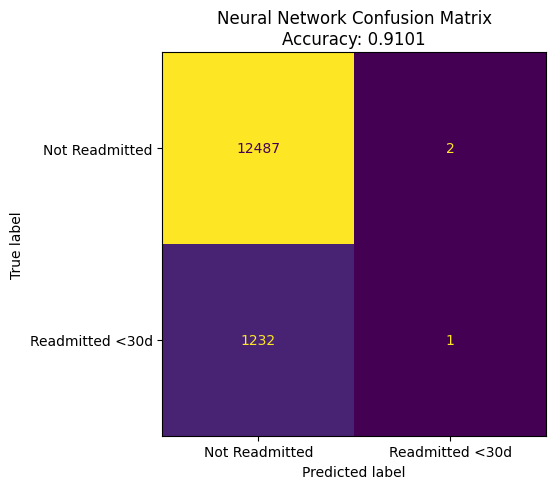

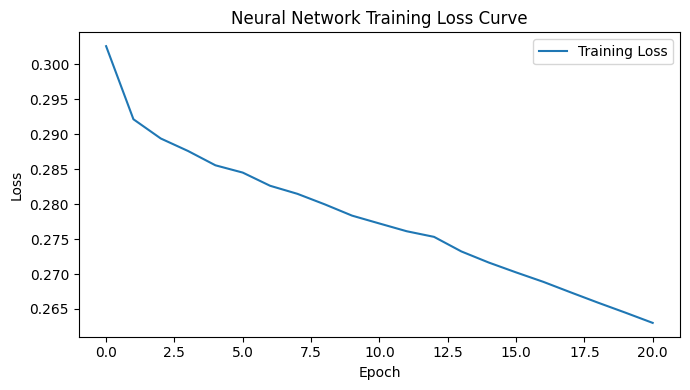


Architecture : input(61) -> hidden(64, ReLU) -> hidden(32, ReLU) -> output(sigmoid)
Epochs run   : 21
Best val score: 0.9104


In [4]:
#neural network with 2 hidden layers
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#encode remaining string cols
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

#scale features for convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#input → hidden(64, ReLU) -> hidden(32, ReLU) -> output
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=seed,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)

#evaluation
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Neural Network Test Accuracy: {acc:.4f}")

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted <30d'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Neural Network Confusion Matrix\nAccuracy: {acc:.4f}")
plt.tight_layout()
plt.show()

#loss curve
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

n_features = X_train.shape[1]
print(f"\nArchitecture : input({n_features}) -> hidden(64, ReLU) -> hidden(32, ReLU) -> output(sigmoid)")
print(f"Epochs run   : {mlp.n_iter_}")
print(f"Best val score: {mlp.best_validation_score_:.4f}")

In [14]:
# kNN classifier
# need to encode categorical columns into numbers
# one hot encoding is required
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# dividing the columns to categorical
categor_cols = ['age', 'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed',
    'diag_1_cat', 'diag_2_cat', 'diag_3_cat']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# we want to apply encoding only to categorical columns
preprocessor = ColumnTransformer(transformers=[('cat', encoder, categor_cols)], remainder='passthrough')

scaler = StandardScaler()

# remove id cols
X_train_small = X_train.drop(columns=['encounter_id', 'patient_nbr'])
X_val_small = X_val.drop(columns=['encounter_id', 'patient_nbr'])
# encode x_train
X_train_encoded = preprocessor.fit_transform(X_train_small)
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_encoded = preprocessor.transform(X_val_small)
X_val_scaled = scaler.transform(X_val_encoded)

k_values = [1, 2, 3, 4, 5, 10, 13, 15, 20, 30]
accuracy_array = []
f1_array = []
for i in range(len(k_values)):
    k = k_values[i]
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    # fit on the training data
    knn_classifier.fit(X_train_scaled, y_train)

    # make predictions on validation test
    y_val_pred = knn_classifier.predict(X_val_scaled)

    # compare predictions to validation labels
    accuracy_val = accuracy_score(y_val, y_val_pred)
    f1_score_val = f1_score(y_val, y_val_pred)
    accuracy_array.append(accuracy_val)
    f1_array.append(f1_score_val)

for i in range(len(k_values)):
    print("k =", k_values[i], "-> Accuracy:", accuracy_array[i], ", F1:", f1_array[i])

print("kNN's best accuracy is 91%. However, it's due to the class imbalance")
print("I choose k = 1 with 84% accuracy because it's F1 score is the highest 0.09")

k = 1 -> Accuracy: 0.8358839819268328 , F1: 0.09120258272800645
k = 2 -> Accuracy: 0.9013263372686198 , F1: 0.01884057971014493
k = 3 -> Accuracy: 0.8890832240198222 , F1: 0.04755944931163955
k = 4 -> Accuracy: 0.9062090074333188 , F1: 0.003098373353989156
k = 5 -> Accuracy: 0.9030024777729194 , F1: 0.017712177121771217
k = 10 -> Accuracy: 0.909998542486518 , F1: 0.0
k = 13 -> Accuracy: 0.9098527911383181 , F1: 0.0
k = 15 -> Accuracy: 0.910071418160618 , F1: 0.0
k = 20 -> Accuracy: 0.910071418160618 , F1: 0.0
k = 30 -> Accuracy: 0.910071418160618 , F1: 0.0
kNN's best accuracy is 91%. However, it's due to the class imbalance
I choose k = 1 with 84% accuracy because it's F1 score is the highest 0.09
